In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import DenseGCNConv
from torch_geometric.utils import to_dense_adj
from torch_geometric.datasets import PPI
from sklearn.metrics import f1_score

path = './data/PPI'
train_dataset = PPI(root=path, split='train')
val_dataset = PPI(root=path, split='val')
test_dataset = PPI(root=path, split='test')

class GCN_PPI_Fixed(nn.Module):
    def __init__(self, train_data):
        super().__init__()
        self.train_adj_params = nn.ParameterList()
        for data in train_data:
            adj_inicial = to_dense_adj(data.edge_index,max_num_nodes=data.num_nodes)[0].clone().float()
            self.train_adj_params.append(nn.Parameter(adj_inicial))
            
        self.gcn1 = DenseGCNConv(train_data.num_features, 256) 
        self.gcn2 = DenseGCNConv(256, train_data.num_classes)

    def normalize_adj(self, adj):
        eye = torch.eye(adj.size(-1), device=adj.device).unsqueeze(0)
        adj_hat = adj + eye
        deg = adj_hat.sum(dim=-1)
        deg_inv_sqrt = deg.pow(-0.5)
        deg_inv_sqrt.masked_fill_(deg_inv_sqrt == float('inf'), 0)
        return deg_inv_sqrt.unsqueeze(-1) * adj_hat * deg_inv_sqrt.unsqueeze(1)

    def forward(self, x, adj_matrix):
        adj_positive = F.relu(adj_matrix).unsqueeze(0)
        adj_norm = self.normalize_adj(adj_positive)
        
        x = self.gcn1(x, adj_norm, add_loop=False)
        x = F.relu(x)
        x = F.dropout(x, p=0.2, training=self.training)
        x = self.gcn2(x, adj_norm, add_loop=False)
        
        return x



In [14]:
def train(model, dataset, optimizer, criterion, device):
    model.train()
    total_loss = 0
    
    for graph_id, data in enumerate(dataset):
        data = data.to(device)
        x_dense = data.x.unsqueeze(0)
        
        optimizer.zero_grad()
        
        adj_treinavel = model.train_adj_params[graph_id]
        
        out = model(x_dense, adj_treinavel)
        
        loss = criterion(out[0], data.y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
    return total_loss / len(dataset)


@torch.no_grad()
def evaluate(model, dataset, criterion, device):
    model.eval()
    total_loss = 0
    y_true, y_pred = [], []
    
    for data in dataset:
        data = data.to(device)
        x_dense = data.x.unsqueeze(0)
        
        adj_original = to_dense_adj(data.edge_index,max_num_nodes=data.num_nodes)[0].float().to(device)
        
        out = model(x_dense, adj_original)
        
        loss = criterion(out[0], data.y)
        total_loss += loss.item()
        
        probs = torch.sigmoid(out[0])
        preds = (probs > 0.5).float()
        
        y_true.append(data.y.cpu())
        y_pred.append(preds.cpu())
        
    y_true = torch.cat(y_true, dim=0).numpy()
    y_pred = torch.cat(y_pred, dim=0).numpy()
    
    f1 = f1_score(y_true, y_pred, average='micro')
    return total_loss / len(dataset), f1

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = GCN_PPI_Fixed(train_dataset).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

train_losses = []
val_losses = []
val_f1_list = []

best_val_acc = 0.0
best_weights = None
best_epoch = 0

for epoch in range(1, 151):
    train_loss = train(model, train_dataset, optimizer, criterion, device)
    val_loss, val_f1 = evaluate(model, val_dataset, criterion, device)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss) 
    val_f1_list.append(val_f1)
    
    if epoch % 10 == 0 or epoch == 1:
        print(f'Epoch {epoch:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val F1: {val_f1:.4f}')


test_loss, test_f1 = evaluate(model, test_dataset, criterion, device)
print(f'F1-Score : {test_f1:.4f}')

Epoch 001 | Train Loss: 0.6130 | Val Loss: 0.5656 | Val F1: 0.4088
Epoch 010 | Train Loss: 0.5141 | Val Loss: 0.5111 | Val F1: 0.4922
Epoch 020 | Train Loss: 0.4794 | Val Loss: 0.4874 | Val F1: 0.5222
Epoch 030 | Train Loss: 0.4537 | Val Loss: 0.4729 | Val F1: 0.5350
Epoch 040 | Train Loss: 0.4367 | Val Loss: 0.4666 | Val F1: 0.5779
Epoch 050 | Train Loss: 0.4169 | Val Loss: 0.4641 | Val F1: 0.5369
Epoch 060 | Train Loss: 0.4055 | Val Loss: 0.4674 | Val F1: 0.5666
Epoch 070 | Train Loss: 0.4320 | Val Loss: 0.4944 | Val F1: 0.6075
Epoch 080 | Train Loss: 0.3967 | Val Loss: 0.4655 | Val F1: 0.5548
Epoch 090 | Train Loss: 0.3759 | Val Loss: 0.4664 | Val F1: 0.5502
Epoch 100 | Train Loss: 0.3647 | Val Loss: 0.4689 | Val F1: 0.5985
Epoch 110 | Train Loss: 0.3560 | Val Loss: 0.4769 | Val F1: 0.6161
Epoch 120 | Train Loss: 0.3429 | Val Loss: 0.4710 | Val F1: 0.5885
Epoch 130 | Train Loss: 0.3313 | Val Loss: 0.4769 | Val F1: 0.5694
Epoch 140 | Train Loss: 0.3224 | Val Loss: 0.4848 | Val F1: 0.

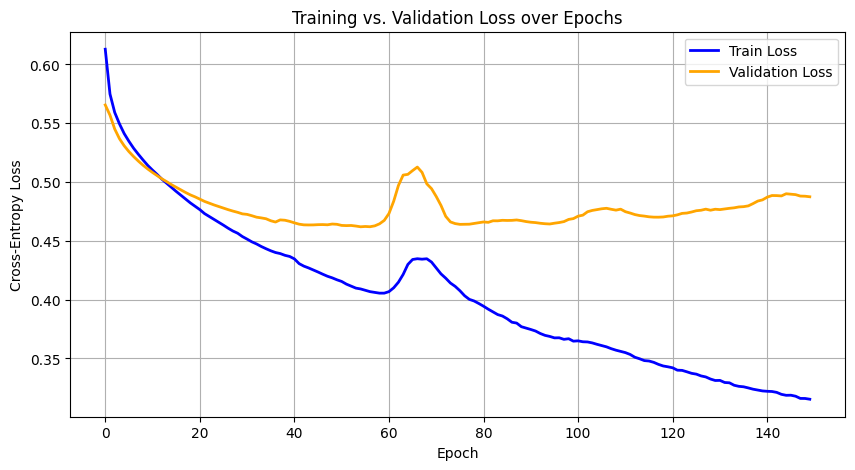

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', color='blue', linewidth=2)
plt.plot(val_losses, label='Validation Loss', color='orange', linewidth=2)
plt.title('Training vs. Validation Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.legend()
plt.grid(True)
plt.show()